# PCA of Qwen Hidden-State Embeddings

This notebook visualizes hidden-state embeddings from `Qwen/Qwen2.5-0.5B` for truthful vs hallucinated examples.

Default setup:

- extract the **last real token** from a configurable hidden-state layer
- use layer `23` by default, matching the strongest K-fold single-layer result so far
- project embeddings to 2D with PCA
- color points by label (`0 = truthful`, `1 = hallucinated`)

In [27]:
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

from model import MAX_LENGTH, get_model_and_tokenizer

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
DATA_FILE = "data/dataset.csv"

# Hidden-state index: 0 = token embeddings, 1..24 = transformer block outputs.
LAYER_INDEX = 1
BATCH_SIZE = 8
N_PER_CLASS = 100  # keep this small for fast notebook iteration
RANDOM_STATE = 42

DEVICE

device(type='cuda')

In [28]:
df = pd.read_csv(DATA_FILE)
df.columns = df.columns.str.strip()

print("Columns:", df.columns.tolist())

if "label" not in df.columns:
    raise KeyError(
        f"Expected a 'label' column in {DATA_FILE}, but found {df.columns.tolist()}. "
        "Use data/dataset.csv for labeled PCA visualization, not data/test.csv."
    )

# Drop unlabeled rows just in case the selected CSV is test-like.
df = df.dropna(subset=["label"]).copy()
df["label"] = df["label"].astype(int)

# Balanced subset for visualization. Avoid groupby.apply because some pandas
# versions drop grouping columns from the result.
parts = []
for label_value in sorted(df["label"].unique()):
    class_df = df[df["label"] == label_value]
    parts.append(
        class_df.sample(
            n=min(len(class_df), N_PER_CLASS),
            random_state=RANDOM_STATE,
        )
    )

df_vis = (
    pd.concat(parts, axis=0)
    .sample(frac=1.0, random_state=RANDOM_STATE)
    .reset_index(drop=True)
)

texts = (df_vis["prompt"].astype(str) + df_vis["response"].astype(str)).tolist()
y = df_vis["label"].to_numpy()

df_vis["label"].value_counts().sort_index(), len(df_vis)

Columns: ['prompt', 'response', 'label']


(label
 0    100
 1    100
 Name: count, dtype: int64,
 200)

In [29]:
model, tokenizer = get_model_and_tokenizer()
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

model.to(DEVICE)
model.eval()

print(f"Device: {DEVICE}")
print(f"Layer index: {LAYER_INDEX}")

[Model] Loading 'Qwen/Qwen2.5-0.5B' ...


Loading weights: 100%|██████████| 290/290 [00:00<00:00, 26817.21it/s]


Device: cuda
Layer index: 1


In [30]:
def extract_last_token_embeddings(texts, layer_idx=LAYER_INDEX, batch_size=BATCH_SIZE):
    """Return last-real-token hidden states from one layer as a NumPy matrix."""
    all_embeddings = []

    for start in range(0, len(texts), batch_size):
        batch_texts = texts[start : start + batch_size]
        encoding = tokenizer(
            batch_texts,
            return_tensors="pt",
            padding=True,
            truncation=True,
            max_length=MAX_LENGTH,
        )
        input_ids = encoding["input_ids"].to(DEVICE)
        attention_mask = encoding["attention_mask"].to(DEVICE)

        with torch.no_grad():
            outputs = model(input_ids=input_ids, attention_mask=attention_mask)

        hidden = outputs.hidden_states[layer_idx].float()  # (batch, seq_len, hidden_dim)
        mask = attention_mask.detach().cpu()

        for i in range(hidden.shape[0]):
            last_pos = int(mask[i].nonzero(as_tuple=False)[-1].item())
            all_embeddings.append(hidden[i, last_pos].detach().cpu().numpy())

    return np.vstack(all_embeddings)

X = extract_last_token_embeddings(texts)
X.shape

(200, 896)

In [31]:
# PCA is sensitive to feature scale, so standardize dimensions first.
X_scaled = StandardScaler().fit_transform(X)

pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_scaled)

print("Explained variance ratio:", pca.explained_variance_ratio_)
print("Total explained variance:", pca.explained_variance_ratio_.sum())

Explained variance ratio: [0.3809109  0.03610955]
Total explained variance: 0.41702044


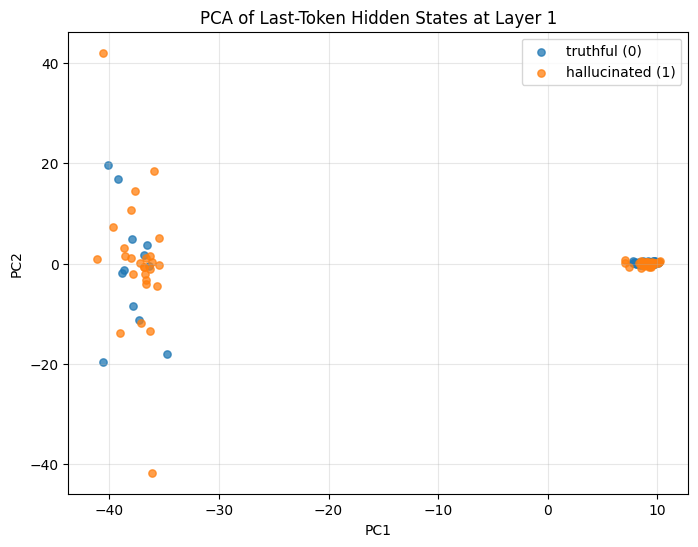

In [32]:
plt.figure(figsize=(8, 6))
colors = {0: "tab:blue", 1: "tab:orange"}
labels = {0: "truthful (0)", 1: "hallucinated (1)"}

for label in [0, 1]:
    idx = y == label
    plt.scatter(
        X_pca[idx, 0],
        X_pca[idx, 1],
        s=28,
        alpha=0.75,
        c=colors[label],
        label=labels[label],
    )

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title(f"PCA of Last-Token Hidden States at Layer {LAYER_INDEX}")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## Layer Sweep: How PCA Structure Changes From Layer 1 to 24

The cells below extract the last-token embedding for every transformer block output (`1..24`) and compute simple layer-wise diagnostics:

- **PC1 AUROC**: how well the first PCA component alone ranks hallucinations
- **PC2 AUROC**: same for second PCA component
- **best signed PC1/PC2 AUROC**: allows either direction (`score` or `-score`)
- **centroid distance in PCA(2D)**: distance between truthful and hallucinated class means after PCA
- **explained variance of PC1+PC2**

This is exploratory only: PCA is unsupervised, so high/low values are hints, not final validation metrics.

# Something with model "energy profile"

In [33]:
from sklearn.metrics import roc_auc_score


def extract_last_token_embeddings_all_layers(texts, batch_size=BATCH_SIZE):
    """Return a dict: layer index -> matrix (n_samples, hidden_dim)."""
    per_layer = {layer_idx: [] for layer_idx in range(1, 25)}

    for start in range(0, len(texts), batch_size):
        batch_texts = texts[start : start + batch_size]
        encoding = tokenizer(
            batch_texts,
            return_tensors="pt",
            padding=True,
            truncation=True,
            max_length=MAX_LENGTH,
        )
        input_ids = encoding["input_ids"].to(DEVICE)
        attention_mask = encoding["attention_mask"].to(DEVICE)

        with torch.no_grad():
            outputs = model(input_ids=input_ids, attention_mask=attention_mask)

        mask = attention_mask.detach().cpu()
        last_positions = [int(mask[i].nonzero(as_tuple=False)[-1].item()) for i in range(mask.shape[0])]

        for layer_idx in range(1, 25):
            hidden = outputs.hidden_states[layer_idx].float()
            for i, last_pos in enumerate(last_positions):
                per_layer[layer_idx].append(hidden[i, last_pos].detach().cpu().numpy())

    return {layer_idx: np.vstack(vectors) for layer_idx, vectors in per_layer.items()}

X_by_layer = extract_last_token_embeddings_all_layers(texts)
{layer: X_by_layer[layer].shape for layer in [1, 12, 22, 23, 24]}

{1: (200, 896), 12: (200, 896), 22: (200, 896), 23: (200, 896), 24: (200, 896)}

In [34]:
def safe_auc(y_true, scores):
    auc = roc_auc_score(y_true, scores)
    return max(auc, 1.0 - auc)  # ignore arbitrary sign flip of PCA axes

layer_rows = []
for layer_idx, X_layer in X_by_layer.items():
    X_scaled = StandardScaler().fit_transform(X_layer)
    pca2 = PCA(n_components=2, random_state=RANDOM_STATE)
    X_2d = pca2.fit_transform(X_scaled)

    truth_centroid = X_2d[y == 0].mean(axis=0)
    hall_centroid = X_2d[y == 1].mean(axis=0)
    centroid_distance = np.linalg.norm(hall_centroid - truth_centroid)

    pc1_auc = roc_auc_score(y, X_2d[:, 0])
    pc2_auc = roc_auc_score(y, X_2d[:, 1])

    layer_rows.append(
        {
            "layer": layer_idx,
            "pc1_auc": pc1_auc,
            "pc2_auc": pc2_auc,
            "best_signed_pc1_auc": max(pc1_auc, 1 - pc1_auc),
            "best_signed_pc2_auc": max(pc2_auc, 1 - pc2_auc),
            "best_signed_pc12_auc": max(
                safe_auc(y, X_2d[:, 0]),
                safe_auc(y, X_2d[:, 1]),
            ),
            "centroid_distance_2d": centroid_distance,
            "explained_var_pc1": pca2.explained_variance_ratio_[0],
            "explained_var_pc2": pca2.explained_variance_ratio_[1],
            "explained_var_pc12": pca2.explained_variance_ratio_.sum(),
        }
    )

layer_metrics = pd.DataFrame(layer_rows)
layer_metrics

,layer,pc1_auc,pc2_auc,best_signed_pc1_auc,best_signed_pc2_auc,best_signed_pc12_auc,centroid_distance_2d,explained_var_pc1,explained_var_pc2,explained_var_pc12
0,1,0.4195,0.4427,0.5805,0.5573,0.5805,6.909030,0.380911,0.036110,0.417020
1,2,0.4212,0.5668,0.5788,0.5668,0.5788,6.898429,0.351507,0.036265,0.387772
2,3,0.5779,0.4045,0.5779,0.5955,0.5955,6.284131,0.290971,0.045531,0.336502
3,4,0.4167,0.4411,0.5833,0.5589,0.5833,6.012339,0.268220,0.042769,0.310988
4,5,0.5651,0.4632,0.5651,0.5368,0.5651,6.875339,0.369457,0.033026,0.402482
5,6,0.4038,0.5889,0.5962,0.5889,0.5962,6.673389,0.340009,0.033526,0.373535
6,7,0.5906,0.5017,0.5906,0.5017,0.5906,7.002846,0.364024,0.030160,0.394184
7,8,0.4111,0.5068,0.5889,0.5068,0.5889,7.118051,0.387701,0.027957,0.415658
8,9,0.4883,0.4956,0.5117,0.5044,0.5117,6.971314,0.411600,0.027896,0.439497
9,10,0.3902,0.4759,0.6098,0.5241,0.6098,6.767844,0.347746,0.035803,0.383549


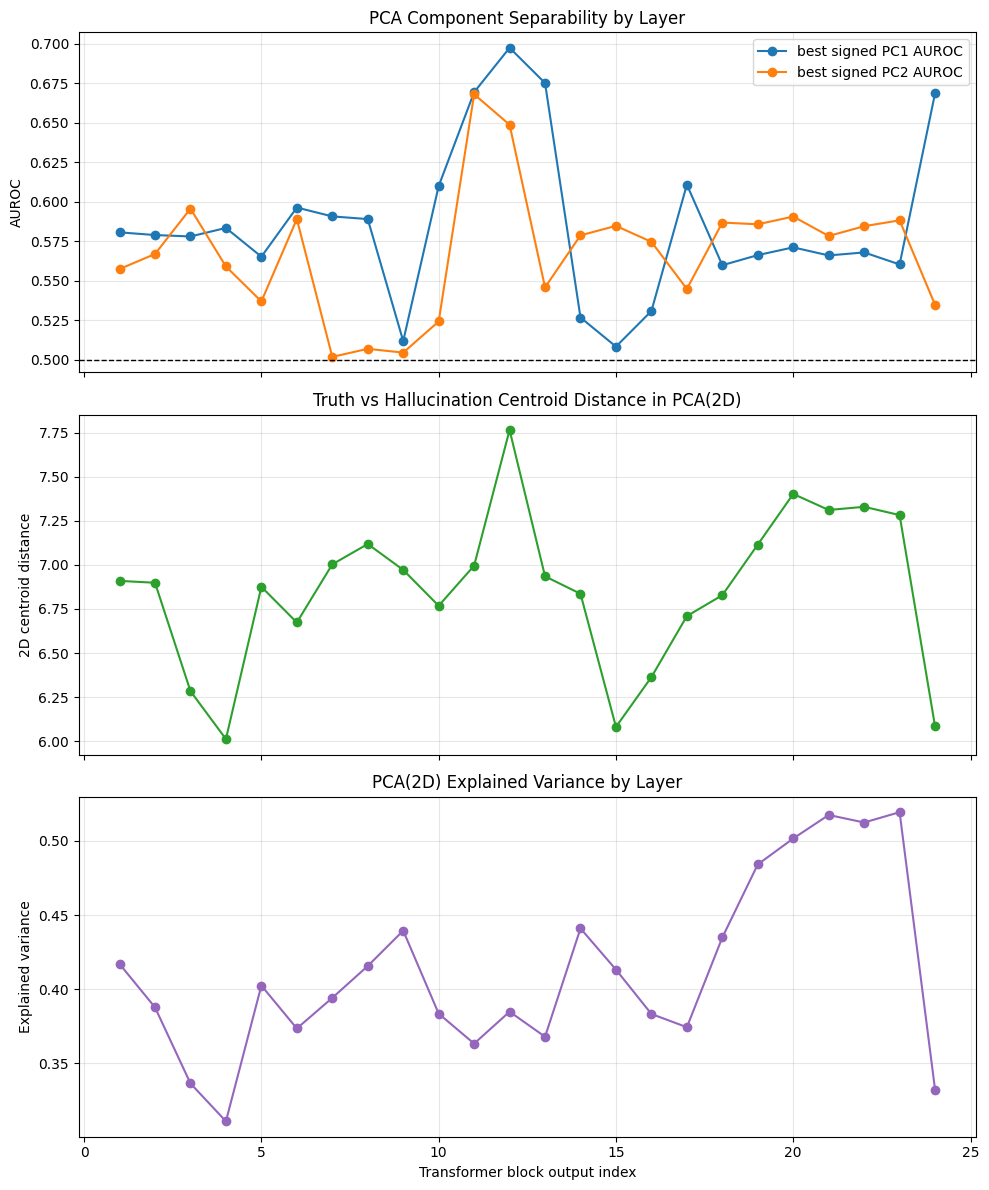

In [35]:
fig, axes = plt.subplots(3, 1, figsize=(10, 12), sharex=True)

axes[0].plot(layer_metrics["layer"], layer_metrics["best_signed_pc1_auc"], marker="o", label="best signed PC1 AUROC")
axes[0].plot(layer_metrics["layer"], layer_metrics["best_signed_pc2_auc"], marker="o", label="best signed PC2 AUROC")
axes[0].axhline(0.5, color="black", linewidth=1, linestyle="--")
axes[0].set_ylabel("AUROC")
axes[0].set_title("PCA Component Separability by Layer")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(layer_metrics["layer"], layer_metrics["centroid_distance_2d"], marker="o", color="tab:green")
axes[1].set_ylabel("2D centroid distance")
axes[1].set_title("Truth vs Hallucination Centroid Distance in PCA(2D)")
axes[1].grid(True, alpha=0.3)

axes[2].plot(layer_metrics["layer"], layer_metrics["explained_var_pc12"], marker="o", color="tab:purple")
axes[2].set_xlabel("Transformer block output index")
axes[2].set_ylabel("Explained variance")
axes[2].set_title("PCA(2D) Explained Variance by Layer")
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [36]:
# Optional: inspect class centroids in PCA space.
centroids = {}
for label in [0, 1]:
    centroids[label] = X_pca[y == label].mean(axis=0)
    print(f"label={label} centroid: {centroids[label]}")

centroid_distance = np.linalg.norm(centroids[1] - centroids[0])
print("Centroid distance in PCA space:", centroid_distance)

label=0 centroid: [ 3.4537706  -0.07176778]
label=1 centroid: [-3.4537687   0.07176778]
Centroid distance in PCA space: 6.9090304


In [37]:
import torch
import pandas as pd
import numpy as np
from model import get_model_and_tokenizer, MAX_LENGTH

device = "cuda" if torch.cuda.is_available() else "cpu"

model, tokenizer = get_model_and_tokenizer()
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

model.to(device)

[Model] Loading 'Qwen/Qwen2.5-0.5B' ...


Loading weights: 100%|██████████| 290/290 [00:00<00:00, 25915.59it/s]


Qwen2ForCausalLM(
  (model): Qwen2Model(
    (embed_tokens): Embedding(151936, 896)
    (layers): ModuleList(
      (0-23): 24 x Qwen2DecoderLayer(
        (self_attn): Qwen2Attention(
          (q_proj): Linear(in_features=896, out_features=896, bias=True)
          (k_proj): Linear(in_features=896, out_features=128, bias=True)
          (v_proj): Linear(in_features=896, out_features=128, bias=True)
          (o_proj): Linear(in_features=896, out_features=896, bias=False)
        )
        (mlp): Qwen2MLP(
          (gate_proj): Linear(in_features=896, out_features=4864, bias=False)
          (up_proj): Linear(in_features=896, out_features=4864, bias=False)
          (down_proj): Linear(in_features=4864, out_features=896, bias=False)
          (act_fn): SiLUActivation()
        )
        (input_layernorm): Qwen2RMSNorm((896,), eps=1e-06)
        (post_attention_layernorm): Qwen2RMSNorm((896,), eps=1e-06)
      )
    )
    (norm): Qwen2RMSNorm((896,), eps=1e-06)
    (rotary_emb): Qwen2

In [38]:
df = pd.read_csv("data/dataset.csv")
row = df.iloc[0]

text = row["prompt"] + row["response"]
label = int(row["label"])

label

1

In [39]:
encoding = tokenizer(
    text,
    return_tensors="pt",
    truncation=True,
    max_length=MAX_LENGTH,
)

input_ids = encoding["input_ids"].to(device)
attention_mask = encoding["attention_mask"].to(device)

with torch.no_grad():
    outputs = model(input_ids=input_ids, attention_mask=attention_mask)

hidden_states = outputs.hidden_states
len(hidden_states), hidden_states[0].shape

(25, torch.Size([1, 213, 896]))

In [40]:
layer_idx = 22

h = hidden_states[layer_idx][0]  # (seq_len, 896)
h.shape

torch.Size([213, 896])

In [41]:
last_pos = int(attention_mask[0].nonzero()[-1])
last_vec = h[last_pos]

last_vec.shape, last_vec[:10]

(torch.Size([896]),
 tensor([-0.5273,  0.0742,  0.0938, -2.5938, -0.3945, -0.6875, -0.5000, -1.1250,
         -2.9531, -1.8281], device='cuda:0', dtype=torch.bfloat16))

In [42]:
last_pos = int(attention_mask[0].nonzero()[-1])

layer_norms = []
for i, layer_h in enumerate(hidden_states):
    vec = layer_h[0, last_pos]
    layer_norms.append(float(torch.linalg.norm(vec).cpu()))

layer_norms

[0.59765625,
 5.25,
 8.8125,
 9.1875,
 9.1875,
 11.8125,
 12.0625,
 12.875,
 14.25,
 15.375,
 13.9375,
 12.75,
 14.5625,
 14.0,
 17.625,
 18.375,
 19.75,
 23.375,
 30.625,
 38.0,
 45.0,
 60.5,
 80.5,
 92.5,
 310.0]

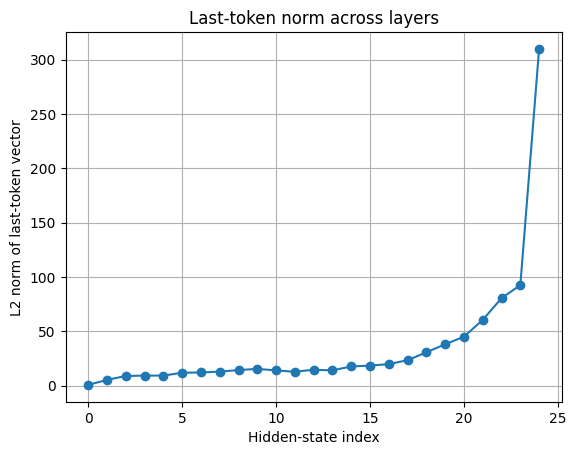

In [43]:
import matplotlib.pyplot as plt

plt.plot(range(len(layer_norms)), layer_norms, marker="o")
plt.xlabel("Hidden-state index")
plt.ylabel("L2 norm of last-token vector")
plt.title("Last-token norm across layers")
plt.grid(True)
plt.show()

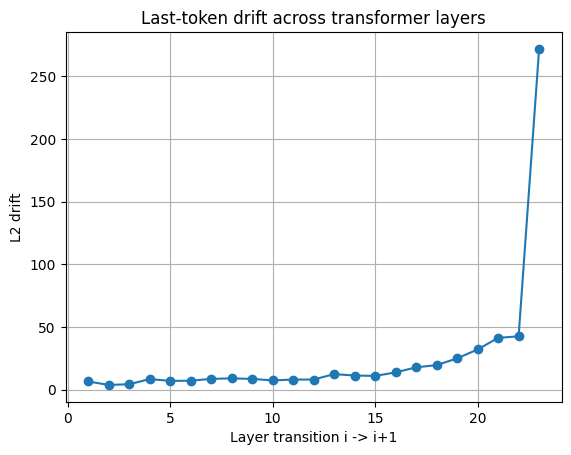

In [44]:
drifts = []
for i in range(1, len(hidden_states) - 1):
    a = hidden_states[i][0, last_pos]
    b = hidden_states[i + 1][0, last_pos]
    drifts.append(float(torch.linalg.norm(b - a).cpu()))

plt.plot(range(1, len(hidden_states) - 1), drifts, marker="o")
plt.xlabel("Layer transition i -> i+1")
plt.ylabel("L2 drift")
plt.title("Last-token drift across transformer layers")
plt.grid(True)
plt.show()

In [45]:
truth_row = df[df["label"] == 0].iloc[0]
hall_row = df[df["label"] == 1].iloc[0]

In [46]:
def get_layer_norms(text, layer_idx=22):
    enc = tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        max_length=MAX_LENGTH,
    ).to(device)

    with torch.no_grad():
        out = model(**enc)

    hs = out.hidden_states
    mask = enc["attention_mask"][0]
    last_pos = int(mask.nonzero()[-1])

    return [
        float(torch.linalg.norm(layer_h[0, last_pos]).cpu())
        for layer_h in hs
    ]

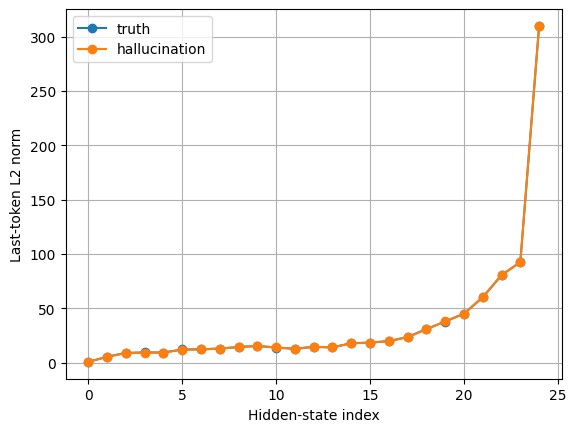

In [47]:
truth_norms = get_layer_norms(truth_row["prompt"] + truth_row["response"])
hall_norms = get_layer_norms(hall_row["prompt"] + hall_row["response"])

plt.plot(truth_norms, marker="o", label="truth")
plt.plot(hall_norms, marker="o", label="hallucination")
plt.xlabel("Hidden-state index")
plt.ylabel("Last-token L2 norm")
plt.legend()
plt.grid(True)
plt.show()

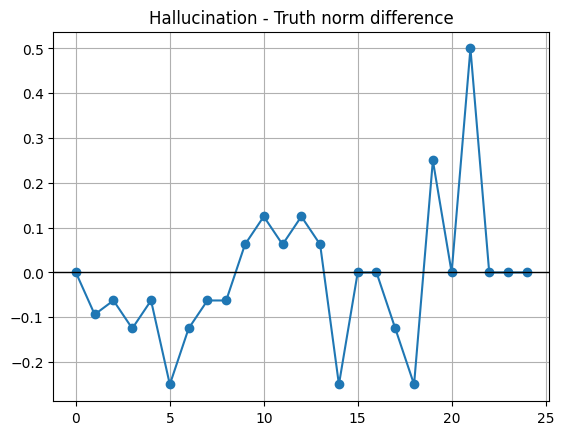

In [48]:
diff = np.array(hall_norms) - np.array(truth_norms)
plt.plot(diff, marker="o")
plt.axhline(0, color="black", linewidth=1)
plt.title("Hallucination - Truth norm difference")
plt.grid(True)
plt.show()